# EXPLORE TSURF POLYGON USING ASTROPY LIBRARY
## Identify if a point falls within a polygon or not

EMM Data is stored in Astropy format.   
**Astropy** is a python library for astronomy. Astropy heavily supports FITS   
**FITS** (Flexible Image Transport System). This is a standard format in astronomy for storing images, tables and other data.   
Astropy provides modules to read, write and and manipulate FITS files
Some modules are - TABLE, UNITS (can store the units of storage) & COORDINATES (e.g right ascension, declination) to store positions in the sky

In this program we explore one FITS file from the EMM data (l3ATM file) and explore how Tsurf is stored. Although we get single values for Lat, Lon and Tsurf, these are actually an average of a polygon area. we explore this area and explore some ways of developing an averaging algorithm for ourselves

In [23]:
import os

from astropy.io import fits
from astropy.table import Table

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.backends.backend_pdf

from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

import geopandas as gpd

import numpy as np
import pandas as pd

import cmasher as cmr

In [2]:
path = '/scratch/da99/marsatm/emm/data/emr/l3atm/2021/02/'
filename = 'emm_emr_l3atm_20210220t112122_0008_f_v04-17.fits'
#filename = 'sample_l3atm_file.fits'
with fits.open(path+filename) as hdul:                
    data = hdul[1].data
    header = hdul[1].header
    t = Table(hdul[1].data)

names = [name for name in t.colnames if len(t[name].shape) <= 1]

pd.DataFrame.from_records(t, columns=t.columns)

,sclk,sclk_sub,det_num,target_type_num,utc,incidence,emission,phase,bore_flag,nfov,...,longitude,qlt,qshgt,target_range,sc_altitude,temp_quality_flag,taudust_quality_flag,tauice_quality_flag,prum_quality_flag,tsurfa_quality_flag
0,666656480,27673,0,0,2021-02-20 11:24:20.929,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,39963.371094,39963.371094,36567.582031,0,0,0,0,0
1,666656482,27700,0,0,2021-02-20 11:24:22.929,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,39962.425781,39962.425781,36566.636719,0,0,0,0,0
2,666656484,27726,0,0,2021-02-20 11:24:24.929,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,39961.484375,39961.484375,36565.691406,0,0,0,0,0
3,666656486,27756,0,0,2021-02-20 11:24:26.93,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,39960.539062,39960.539062,36564.746094,0,0,0,0,0
4,666656488,27777,5,3,2021-02-20 11:24:28.93,0.0,0.0,0.0,0,2.648076,...,0.0,0.0,39959.593750,39959.593750,36563.804688,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,0,0,0,0,,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0
388,0,0,0,0,,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0
389,0,0,0,0,,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0
390,0,0,0,0,,0.0,0.0,0.0,0,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0


In [3]:
# Header gives the details of all the columns 

header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 3579 / length of dimension 1                          
NAXIS2  =                  392 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   50 / number of table fields                         
EXTNAME = 'l3atm   '           / name of this binary table extension            
MIN_SCLK=            666656480                                                  
MAX_SCLK=            666657212                                                  
CAL_SEQ =                 1429                                                  
PRODUCER= 'EMIRS/ASU-NAU'   

In [4]:
# Using astropy
hdu_list = fits.open(path+filename, memmap=True)

In [5]:
# Exploring the contents
hdu_list.info()

Filename: /scratch/da99/marsatm/emm/data/emr/l3atm/2021/02/emm_emr_l3atm_20210220t112122_0008_f_v04-17.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  l3atm         1 BinTableHDU    117   392R x 50C   [1J, 1J, 1B, 1B, 23A, 1E, 1E, 1E, 1B, 1E, 1E, 1D, 1D, 30D, 30D, 1J, 20D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1J, 1D, 1D, 333D, 1D, 1E, 1E, 1E, 1D, 1D, 1D, 1B, 1B, 1B, 1B, 1B]   


In [6]:
# We are interested in the l3atm
#To find out what information the table contains, let's print the column names.

print(hdu_list[1].columns)

ColDefs(
    name = 'sclk'; format = '1J'
    name = 'sclk_sub'; format = '1J'
    name = 'det_num'; format = '1B'
    name = 'target_type_num'; format = '1B'
    name = 'utc'; format = '23A'
    name = 'incidence'; format = '1E'
    name = 'emission'; format = '1E'
    name = 'phase'; format = '1E'
    name = 'bore_flag'; format = '1B'
    name = 'nfov'; format = '1E'
    name = 'scan_period'; format = '1E'
    name = 'ra'; format = '1D'
    name = 'dec'; format = '1D'
    name = 'x2d'; format = '30D'
    name = 'y2d'; format = '30D'
    name = 'npts2d'; format = '1J'
    name = 'temp'; format = '20D'
    name = 'shift'; format = '1D'
    name = 'tsurfco2'; format = '1D'
    name = 'chi2temp'; format = '1D'
    name = 'pres0'; format = '1D'
    name = 'taudust'; format = '1D'
    name = 'tauice'; format = '1D'
    name = 'tsurfa'; format = '1D'
    name = 'dustuncert'; format = '1D'
    name = 'iceuncert'; format = '1D'
    name = 'chi2a'; format = '1D'
    name = 'zdust'; format = '1

In [7]:
#Now we'll take this data and convert it into an astropy table. 
#While it's possible to access FITS tables directly from the .data attribute, 
#using Table tends to make a variety of common tasks more convenient.

evt_data = Table(hdu_list[1].data)


In [8]:
evt_data

sclk,sclk_sub,det_num,target_type_num,utc,incidence,emission,phase,bore_flag,nfov,scan_period,ra,dec,x2d,y2d,npts2d,temp,shift,tsurfco2,chi2temp,pres0,taudust,tauice,tsurfa,dustuncert,iceuncert,chi2a,zdust,prum,zh2o,tsurfh2o,wateruncert,chi2b,ierr,ccsds_id,qnvv,qvv,qobsrad,qls,latitude,longitude,qlt,qshgt,target_range,sc_altitude,temp_quality_flag,taudust_quality_flag,tauice_quality_flag,prum_quality_flag,tsurfa_quality_flag
int32,int32,uint8,uint8,str23,float32,float32,float32,uint8,float32,float32,float64,float64,float64[30],float64[30],int32,float64[20],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,float64,float64,float64[333],float64,float32,float32,float32,float64,float64,float64,uint8,uint8,uint8,uint8,uint8
666656480,27673,0,0,2021-02-20 11:24:20.929,0.0,0.0,0.0,0,0.0,2.0,0.0,0.0,0.0 .. 0.0,0.0 .. 0.0,0,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,171.0,10.55090045928955,0.0 .. 0.0,6.435436248779297,0.0,0.0,0.0,39963.37109375,39963.37109375,36567.58203125,0,0,0,0,0
666656482,27700,0,0,2021-02-20 11:24:22.929,0.0,0.0,0.0,0,0.0,2.0,0.0,0.0,0.0 .. 0.0,0.0 .. 0.0,0,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,21.1018009185791,0.0 .. 0.0,6.435447692871094,0.0,0.0,0.0,39962.42578125,39962.42578125,36566.63671875,0,0,0,0,0
666656484,27726,0,0,2021-02-20 11:24:24.929,0.0,0.0,0.0,0,0.0,2.0,0.0,0.0,0.0 .. 0.0,0.0 .. 0.0,0,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,31.652700424194336,0.0 .. 0.0,6.435459136962891,0.0,0.0,0.0,39961.484375,39961.484375,36565.69140625,0,0,0,0,0
666656486,27756,0,0,2021-02-20 11:24:26.93,0.0,0.0,0.0,0,0.0,2.0,0.0,0.0,0.0 .. 0.0,0.0 .. 0.0,0,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,42.2036018371582,0.0 .. 0.0,6.435470104217529,0.0,0.0,0.0,39960.5390625,39960.5390625,36564.74609375,0,0,0,0,0
666656488,27777,5,3,2021-02-20 11:24:28.93,0.0,0.0,0.0,0,2.648076,2.0,355.2607727050781,-23.286823272705078,342.14398193359375 .. 0.0,-9.470465660095215 .. 0.0,21,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,11200084,0.0,52.75450134277344,0.0 .. 0.0,6.435481548309326,0.0,0.0,0.0,39959.59375,39959.59375,36563.8046875,0,0,0,0,0
666656490,27803,5,3,2021-02-20 11:24:30.931,0.0,0.0,0.0,0,2.3709748,2.0,354.9989929199219,-22.703800201416016,343.06817626953125 .. 0.0,-3.003312587738037 .. 0.0,21,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,11200093,0.0,63.30540084838867,0.0 .. 0.0,6.435492992401123,0.0,0.0,0.0,39958.6484375,39958.6484375,36562.859375,0,0,0,0,0
666656492,27831,5,3,2021-02-20 11:24:32.931,0.0,0.0,0.0,0,2.3379474,2.0,354.7442321777344,-22.11772918701172,343.9994201660156 .. 0.0,3.5917749404907227 .. 0.0,21,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,11200102,0.0,73.8563003540039,0.0 .. 0.0,6.43550443649292,0.0,0.0,0.0,39957.70703125,39957.70703125,36561.9140625,0,0,0,0,0
666656494,27856,5,3,2021-02-20 11:24:34.931,0.0,0.0,0.0,0,2.5344186,2.0,354.4916076660156,-21.531267166137695,344.93487548828125 .. 0.0,10.12177848815918 .. 0.0,21,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,11200111,0.0,84.40730285644531,0.0 .. 0.0,6.435515403747559,0.0,0.0,0.0,39956.76171875,39956.76171875,36560.96875,0,0,0,0,0
666656496,27886,5,3,2021-02-20 11:24:36.932,0.0,0.0,0.0,0,2.9488516,2.0,354.2398681640625,-20.94522476196289,345.874267578125 .. 0.0,16.421194076538086 .. 0.0,21,0.0 .. 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,11200120,0.0,94.95819854736328,0.0 .. 0.0,6.4355268478393555,0.0,0.0,0.0,39955.81640625,39955.81640625,36560.02734375,0,0,0,0,0


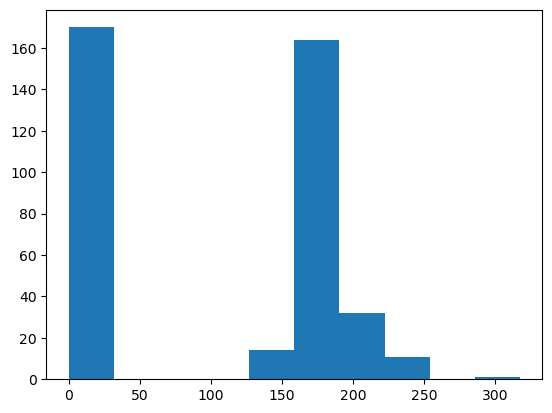

In [9]:
# histogram
emiss_hist = plt.hist(evt_data['tsurfa'], bins='auto')

In [10]:
evt_data['x2d'][200][np.nonzero(evt_data['x2d'][200])]

array([131.05290222, 130.70729065, 130.04039001, 129.09039307,
       127.91474152, 126.59574127, 125.24442291, 123.99838257,
       123.00926208, 122.41838074, 122.32474518, 122.75628662,
       106.23925781, 100.35558319,  99.82633209, 101.00936127,
       103.873703  , 111.46649933, 130.70155334, 131.05407715,
       131.05290222], dtype='>f8')

(65.0, 72.0)

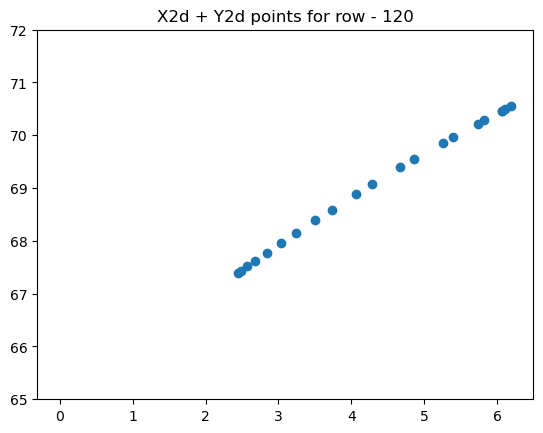

In [12]:
point = 120
plt.scatter(x=t['x2d'][point], y=t['y2d'][point])
plt.title('X2d + Y2d points for row - ' + str(point))
plt.ylim([65, 72])


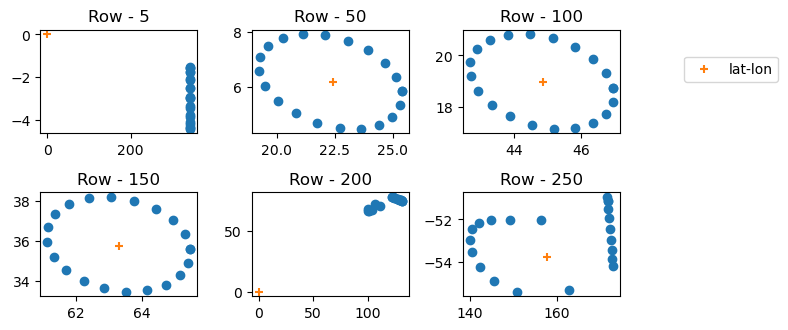

In [13]:
# using the variable ax for single a Axes
#fig, ax = plt.subplots()
points = [5, 50, 100, 150, 200, 250]
points_len = int(len(points)/2)
plot_counter = 0

for index, point in enumerate(points):
    #print(points_len,index, point)
    plt.subplot(points_len, points_len, index+1)
    x_num = evt_data['x2d'][point][np.nonzero(evt_data['x2d'][point])]
    y_num = evt_data['y2d'][point][np.nonzero(evt_data['y2d'][point])]
    plt.scatter(x=x_num, y=y_num)
    plt.scatter(y=evt_data['latitude'][point], x = evt_data['longitude'][point], marker='+', label='lat-lon')
    plt.title('Row - ' + str(point))
    

plt.tight_layout()
plt.legend(bbox_to_anchor=(2.05, 2.0),loc='lower right')
plt.show()
    
#    fig, axs = plt.subplots(points_len, points_len)
#    axs[i,j].scatter(x=t['x2d'][point[point_index]], y=t['y2d'][point[point_index]])
#    axs[i,j].set_title('Row - ' + str(point[point_index]))

# using the variable axs for multiple Axes
#fig, axs = plt.subplots(2, 2)
#axs[0,0].scatter(x=t['x2d'][point[0]], y=t['y2d'][point[0]])
#axs[0,0].set_title('Row - ' + str(point[0]))

#axs[0,1].scatter(x=t['x2d'][point[1]], y=t['y2d'][point[1]])
#axs[0,1].set_title('Row - ' + str(point[1]))


In [16]:
# Use polygon to check if point inside or not

point = Point(0.5, 0.5)
polygon = Polygon([(0, 0), (0, 1), (1, 1), (1, 0)])
print(polygon.contains(point))

True


In [18]:
# Unpack 1 polygon

poly_points = []

for i in range(0,21):
    poly_points.append((evt_data['x2d'][250][i],evt_data['y2d'][250][i]) )

poly_points

[(171.6976318359375, -51.149532318115234),
 (171.62570190429688, -50.94972229003906),
 (156.2725372314453, -52.041236877441406),
 (149.21115112304688, -52.01441955566406),
 (145.0052032470703, -52.00788116455078),
 (142.23463439941406, -52.15053176879883),
 (140.6088409423828, -52.46870803833008),
 (140.06434631347656, -52.951904296875),
 (140.63316345214844, -53.56270217895508),
 (142.41773986816406, -54.23967361450195),
 (145.62725830078125, -54.89702606201172),
 (150.80865478515625, -55.412315368652344),
 (162.85015869140625, -55.351993560791016),
 (172.88250732421875, -54.20063400268555),
 (172.75498962402344, -53.892826080322266),
 (172.58279418945312, -53.46967697143555),
 (172.3845672607422, -52.97153854370117),
 (172.17967224121094, -52.443965911865234),
 (171.98651123046875, -51.93441390991211),
 (171.8213348388672, -51.489044189453125),
 (171.6976318359375, -51.149532318115234)]

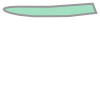

In [19]:
polygon = Polygon(poly_points)
polygon
#point

In [22]:
# For a small area, check how well we can understand if a point is inside a polygon or not
true_list = []
false_list = []
for i in range(140, 171):
    for j in range(-56, -50):
        point = Point(i, j)
        #print(i,j)
        #print(polygon.contains(point))
        if polygon.contains(point):
            true_list.append((i,j))
        else:
            false_list.append((i,j))
        

In [24]:
# Use Geopandas to plot 

mploy = gpd.GeoSeries(polygon)

mploy.plot(

Text(0.5, 1.0, 'Points inside a polygon')

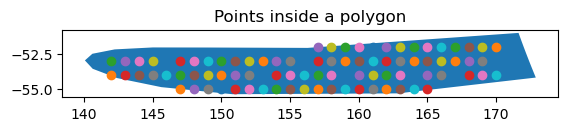

In [26]:
mploy.plot()
for i in true_list:
    plt.scatter(x = i[0], y = i[1])
plt.title("Points inside a polygon")

Text(0.5, 1.0, 'Points outside a polygon')

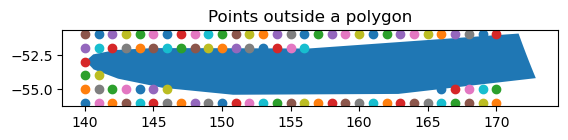

In [27]:
mploy.plot()
for i in false_list:
    plt.scatter(x = i[0], y = i[1])
    
plt.title("Points outside a polygon")

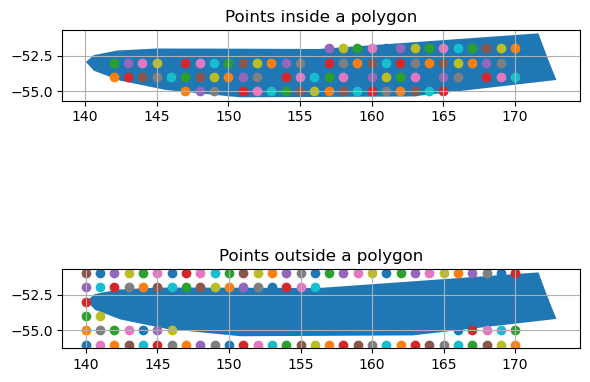

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6))  # 2 rows, 1 column. Adjust figsize as needed

# First subplot: Points inside the polygon
mploy.plot(ax = axs[0])
for i in true_list:
    axs[0].scatter(x=i[0], y=i[1]) # Scatter points inside
axs[0].set_title("Points inside a polygon")
axs[0].grid(True)

# Second subplot: Points outside the polygon
mploy.plot(ax = axs[1])
for i in false_list:
    axs[1].scatter(x=i[0], y=i[1])  # Scatter points outside
axs[1].set_title("Points outside a polygon")
axs[1].grid(True)

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

<Axes: >

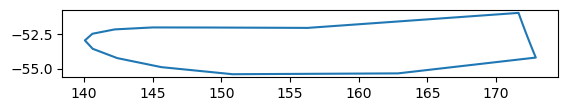

In [35]:
mploy.boundary.plot()